In [1]:
from pathlib import Path
import geopandas as gpd
import pandas as pd

In [2]:
BASE_DIR = Path.cwd().parent
CLEAN_DIR = BASE_DIR / "data" / "clean"

ped_grid_path = CLEAN_DIR / "grid_250m_with_pedestrian_proxy.gpkg"

print("BASE_DIR:", BASE_DIR)
print("File exists:", ped_grid_path.exists())
print("Path:", ped_grid_path)

BASE_DIR: c:\Toronto_Waste
File exists: True
Path: c:\Toronto_Waste\data\clean\grid_250m_with_pedestrian_proxy.gpkg


In [3]:
grid_ped = gpd.read_file(ped_grid_path, layer="grid_pedestrian")

grid_ped.head()

,cell_id,bins_total,bins_park_assets,bins_street_furniture,has_bins,pedestrian_length_m,geometry
0,0,0,0,0,False,0.0,"POLYGON ((607837.395 4824768.166, 607837.395 4..."
1,1,0,0,0,False,0.0,"POLYGON ((607837.395 4825018.166, 607837.395 4..."
2,2,0,0,0,False,0.0,"POLYGON ((607837.395 4825268.166, 607837.395 4..."
3,3,0,0,0,False,0.0,"POLYGON ((607837.395 4825518.166, 607837.395 4..."
4,4,0,0,0,False,0.0,"POLYGON ((607837.395 4825768.166, 607837.395 4..."


In [4]:
print("CRS:", grid_ped.crs)
print("Number of cells:", len(grid_ped))
print("Cells with pedestrian_length_m > 0:", int((grid_ped["pedestrian_length_m"] > 0).sum()))
print("Max pedestrian_length_m:", float(grid_ped["pedestrian_length_m"].max()))

CRS: EPSG:26917
Number of cells: 25024
Cells with pedestrian_length_m > 0: 9107
Max pedestrian_length_m: 4010.15753985


In [5]:
grid_ped["pedestrian_length_m"].describe()

count    25024.000000
mean       320.807280
std        518.559569
min          0.000000
25%          0.000000
50%          0.000000
75%        602.100060
max       4010.157540
Name: pedestrian_length_m, dtype: float64

In [6]:
grid_ped.sort_values("pedestrian_length_m", ascending=False)[
    ["cell_id", "pedestrian_length_m"]
].head(10)

,cell_id,pedestrian_length_m
14320,14320,4010.157540
9700,9700,3457.436750
10789,10789,3209.723460
3456,3456,3097.853586
13778,13778,2994.277318
9833,9833,2987.949203
9569,9569,2971.295533
14461,14461,2881.388203
5774,5774,2833.522851
12163,12163,2799.755589


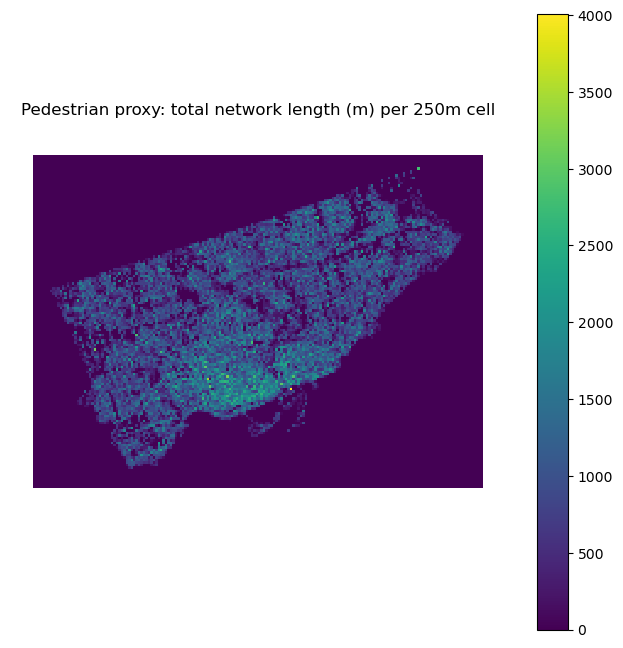

In [7]:
ax = grid_ped.plot(column="pedestrian_length_m", legend=True, figsize=(8, 8))
ax.set_title("Pedestrian proxy: total network length (m) per 250m cell")
ax.set_axis_off()

In [ ]:
#Purpose
# Build a pedestrian activity proxy from the Pedestrian Network dataset and integrate it into the 250m analysis grid.
# Steps:
# Load pedestrian network (geometry in EPSG:4326) and convert GeoJSON geometry strings into valid line geometries.
# Reproject to EPSG:26917.
# Spatially join segments to the 250m grid and aggregate total segment length per cell.
# Validation
# Confirmed meaningful variation across cells (zeros in areas without pedestrian infrastructure and higher values in dense zones).
# Output:
# data/clean/grid_250m_with_pedestrian_proxy.gpkg (layer: grid_pedestrian)